## Insider Threat Radar – Behavior Analytics for Employee Risk Prediction

### Stacking_Ensemble

#### Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

#### Load Data

In [2]:
data = pd.read_csv("../Dataset/anomaly_output.csv")

feature_cols = [
    'total_emails','total_attachments','avg_email_size',
    'off_hour_emails','weekend_emails',
    'O','C','E','A','N'
]

X = data[feature_cols]
y = data['anomaly_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Define stacking model

In [3]:
stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced')),
        ('gb', GradientBoostingClassifier()),
        ('mlp', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300))
    ],
    final_estimator=LogisticRegression()
)

#### Train Stacking Ensemble

In [4]:
stack.fit(X_train, y_train)

StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       n_estimators=200)),
                               ('gb', GradientBoostingClassifier()),
                               ('mlp',
                                MLPClassifier(hidden_layer_sizes=(64, 32),
                                              max_iter=300))],
                   final_estimator=LogisticRegression())

#### Evaluation

In [5]:
stack_pred = stack.predict(X_test)

#### Confusion Matrix & Classification Report

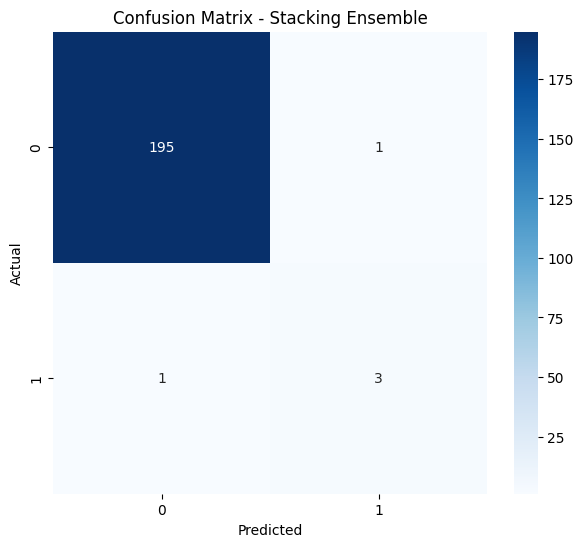


📄 CLASSIFICATION REPORT - STACKING ENSEMBLE

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       196
           1       0.75      0.75      0.75         4

    accuracy                           0.99       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.99      0.99      0.99       200



In [6]:
cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Stacking Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📄 CLASSIFICATION REPORT - STACKING ENSEMBLE\n")
print(classification_report(y_test, stack_pred))

#### Save Model

In [7]:
joblib.dump(stack, "../Model/stacking_model.pkl")
print("Stacking model saved ✅")

Stacking model saved ✅
